<h1><b>Predviđanje Smera Kretanja Cene Bitcoina putem LSTM Modela</b></h1>

Cilj projekta je klasifikacija smera kretanja cene Bitcoina korišćenjem metoda mašinskog učenja i neuronskih mreža. Zadatak je da se na osnovu prethodnih vrednosti predvidi da li će cena rasti (UP), opadati (DOWN) ili ostati stabilna (STABLE).

Klasifikacija se vrši na osnovu procentualne promene cene, pri čemu se koriste pragovi definisani u zadatku (±2%).

<h2>Izbor i prikupljanje podataka</h2>

Za potrebe projekta korišćeni su istorijski podaci o ceni Bitcoina preuzeti sa Binance platforme putem njihovog API-ja. Izabran je trading par BTC/USDT zato što predstavlja jedan od najlikvidnijih i najtrgovanijih parova, što znači da su podaci stabilni i bez većih prekida. Podaci su prikupljeni u vremenskom intervalu od jednog sata, jer manji intervali uvode previše šuma u podatke, dok veći intervali gube značajan deo informacija o kratkoročnim promenama cene.

Isti skup podataka korišćen je i za klasifikacioni zadatak, gde su na osnovu promena u ceni generisane diskretne klase (UP, DOWN, STABLE).

<h2>Opis prikupljanja podataka</h2>

Podaci su preuzimani korišćenjem Binance API-ja za OHLCV podatke, koji uključuju vrednosti Open, High, Low, Close i Volume. Zbog ograničenja API-ja, gde je moguće dobiti maksimalno 1000 zapisa po zahtevu, podaci su preuzimani u više iteracija, tako što se svaki naredni zahtev nadovezuje na prethodni vremenski opseg. Nakon preuzimanja, timestamp vrednosti su konvertovane u datetime format, a podaci su organizovani u pandas DataFrame i zadržane su samo relevantne kolone potrebne za dalju analizu.

<h3>Zašto nije korišćen yfinace API</h3>

Iako je u početnoj specifikaciji predloženo korišćenje Yahoo Finance API-ja, u ovom radu je umesto toga korišćen Binance API, pošto Binance omogućava jednostavniji pristup dužim vremenskim serijama i podržava kraće vremenske intervale, kao što je jedan sat, bez dodatnih ograničenja. Ovo je bilo važno jer model zahteva veću količinu podataka kako bi mogao da nauči obrasce u vremenskoj seriji.

<h2>Razlog izbora ovog dataset-a</h2>

Izabrani dataset je pogodan za ovaj zadatak jer predstavlja realne finansijske podatke i ima strukturu vremenske serije, i to omogućava primenu modela kao što je LSTM. Takođe, količina dostupnih podataka je dovoljna za treniranje modela, a kontinuiranost serije omogućava stabilniju analizu. Dodatno, Bitcoin je poznat po svojoj volatilnosti, što ovaj problem čini izazovnijim i zanimljivijim za istraživanje.

In [17]:
'''
import pandas as pd
import requests
import datetime
import time

def get_binance_klines(symbol="BTCUSDT", interval="1h", start="2017-01-01"):# skida istorijske Bitcoin cene sa Binance API.
    """
    #Download historical OHLCV data from Binance.
    #interval examples: 1m, 5m, 15m, 1h, 4h, 1d
    """
    
    url = "https://api.binance.com/api/v3/klines"# endpoint za price data.
    start_ts = int(pd.Timestamp(start).timestamp() * 1000)# pretvara datum u timestamp.
    end_ts = int(time.time() * 1000)

    all_data = []

    while start_ts < end_ts:# Skida podatke u batch-evima jer API ima limit.
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": start_ts,
            "limit": 1000  # Binance max per request
        }

        data = requests.get(url, params=params).json()

        # Stop if Binance returns empty list (end of available data)
        if not data:
            break

        all_data.extend(data)

        # Move start to last returned timestamp + 1ms
        last_time = data[-1][0]
        start_ts = last_time + 1

        # avoid hitting rate limit
        time.sleep(0.4)

    # Convert into DataFrame
    df = pd.DataFrame(all_data, columns=[
        "OpenTime", "Open", "High", "Low", "Close", "Volume",
        "CloseTime", "QuoteVolume", "Trades", "TakerBuyBase",
        "TakerBuyQuote", "Ignore"
    ])

    # Clean up
    df["OpenTime"] = pd.to_datetime(df["OpenTime"], unit="ms")
    df = df.set_index("OpenTime")

    df = df[["Open", "High", "Low", "Close", "Volume"]].astype(float)

    # Rename to match yfinance naming style
    df.index.name = "Datetime"

    return df
'''

'\nimport pandas as pd\nimport requests\nimport datetime\nimport time\n\ndef get_binance_klines(symbol="BTCUSDT", interval="1h", start="2017-01-01"):# skida istorijske Bitcoin cene sa Binance API.\n    """\n    #Download historical OHLCV data from Binance.\n    #interval examples: 1m, 5m, 15m, 1h, 4h, 1d\n    """\n\n    url = "https://api.binance.com/api/v3/klines"# endpoint za price data.\n    start_ts = int(pd.Timestamp(start).timestamp() * 1000)# pretvara datum u timestamp.\n    end_ts = int(time.time() * 1000)\n\n    all_data = []\n\n    while start_ts < end_ts:# Skida podatke u batch-evima jer API ima limit.\n        params = {\n            "symbol": symbol,\n            "interval": interval,\n            "startTime": start_ts,\n            "limit": 1000  # Binance max per request\n        }\n\n        data = requests.get(url, params=params).json()\n\n        # Stop if Binance returns empty list (end of available data)\n        if not data:\n            break\n\n        all_data.e

<h2>Učitavanje podataka</h2>

Podaci su nakon preuzimanja sačuvani u CSV fajl i zatim učitani pomoću pandas biblioteke. Prilikom učitavanja, vremenska kolona je postavljena kao indeks i konvertovana u datetime format, kako bi se zadržala struktura vremenske serije. Ovo omogućava jednostavniji rad sa podacima u daljim koracima.

Poslečitavanja, prikazuje se prvih nekoliko redova dataset-a kako bi se videlo kako podaci izgledaju. Vremenska kolona je indeksirana, a prisutne su osnovne vrednosti kao što su Open, High, Low, Close i Volume, koje će se dalje koristiti u modelu.

In [18]:
#df = get_binance_klines("BTCUSDT", interval="1h", start="2017-01-01")# skida Bitcoin cenu po satu od 2017.
#df.head()# prikaz prvih redova
!pip install -q pandas
import pandas as pd
df = pd.read_csv("btc_1h.csv", index_col=0, parse_dates=True)# ucitavanje podataka
df.head()

,Open,High,Low,Close,Volume
Datetime,,,,,
2017-08-17 04:00:00,4261.48,4313.62,4261.32,4308.83,47.181009
2017-08-17 05:00:00,4308.83,4328.69,4291.37,4315.32,23.234916
2017-08-17 06:00:00,4330.29,4345.45,4309.37,4324.35,7.229691
2017-08-17 07:00:00,4316.62,4349.99,4287.41,4349.99,4.443249
2017-08-17 08:00:00,4333.32,4377.85,4333.32,4360.69,0.972807


<h2>Kreiranje dodatnih karakteristika</h2>

U cilju poboljšanja performansi modela, nad osnovnim podacima su generisane dodatne karakteristike koje opisuju kretanje cene kroz vreme. Ove karakteristike uključuju različite tipove informacija, kao što su procentualne promene cene, statističke mere, kao i tehnički indikatori koji se često koriste u finansijskoj analizi.

Korišćene su promene cene kroz vreme, kao što su povrat u poslednjem satu i dnevni povrat, kako bi model lakše uočio relativne promene umesto apsolutnih vrednosti. Takođe su izračunate pokretne sredine i standardne devijacije koje daju uvid u trend i volatilnost u određenom vremenskom prozoru.

Dodatno, korišćene su tzv. lag vrednosti, odnosno prethodne cene u određenim vremenskim trenucima, čime se modelu omogućava da uči iz istorijskih obrazaca. Pored toga, uključeni su i tehnički indikatori kao što su RSI, MACD, Bollinger Bands, kao i SMA i EMA, koji predstavljaju standardne alate u analizi tržišta.

Na kraju, definisane su ciljne promenljive koje predstavljaju buduću cenu nakon određenog vremenskog perioda (24h, 48h i 7 dana), čime se formuliše zadatak predikcije.

Ispod je ispisana nova tabela

In [19]:
!pip install -q ta
import ta

#return
df["return_1h"] = df["Close"].pct_change()# koliko se cena promenila u % zato što model lakše uči promene nego apsolutne cene.
df['daily_return'] = df['Close'].pct_change(24)# Dnevni prinos
#mean/std
df["rolling_mean_24h"] = df["Close"].rolling(24).mean()# prosečna cena zadnja 24h
df["rolling_std_24h"] = df["Close"].rolling(24).std()# volatilnost
#lag
df["close_lag_6h"] = df["Close"].shift(6)# cena pre 6h
df["close_lag_12h"] = df["Close"].shift(12)# cena pre 12h
df["close_lag_24h"] = df["Close"].shift(24)# cena pre 24h
df['close_lag_48h'] = df['Close'].shift(48)  # Cena pre 48h
df['close_lag_168h'] = df['Close'].shift(168)  # Cena pre 7 dana

# RSI
df['RSI_14'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

# MACD
macd = ta.trend.MACD(df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()  # MACD signal linija
df['MACD_hist'] = macd.macd_diff()  # MACD histogram

# Bollinger Bands
bb = ta.volatility.BollingerBands(df['Close'], window=20, window_dev=2)
df['BB_mavg'] = bb.bollinger_mavg()  # Srednja Bollinger linija
df['BB_upper'] = bb.bollinger_hband()  # Gornja Bollinger linija
df['BB_lower'] = bb.bollinger_lband()  # Donja Bollinger linija

# SMA i EMA
df['SMA_20'] = ta.trend.SMAIndicator(df['Close'], window=20).sma_indicator()
df['EMA_20'] = ta.trend.EMAIndicator(df['Close'], window=20).ema_indicator()

# ATR (Average True Range)
df['ATR_14'] = ta.volatility.AverageTrueRange(high=df['High'], low=df['Low'], close=df['Close'], window=14).average_true_range()

# ROC (Rate of Change) - Procenat promene cene u poslednjem periodu
df['ROC'] = ta.momentum.ROCIndicator(df['Close'], window=12).roc()

df = df.dropna()# brisanje jer rolling i lag nekada stvaraju prazne vrednosti.
df.head() #ispis :)

,Open,High,Low,Close,Volume,return_1h,daily_return,rolling_mean_24h,rolling_std_24h,close_lag_6h,...,MACD,MACD_signal,MACD_hist,BB_mavg,BB_upper,BB_lower,SMA_20,EMA_20,ATR_14,ROC
Datetime,,,,,,,,,,,,,,,,,,,,,
2017-08-24 04:00:00,4113.58,4148.19,4090.39,4113.98,32.247571,0.000097,0.007440,4145.985833,52.439849,4114.20,...,14.272129,26.070185,-11.798056,4158.5800,4249.760962,4067.399038,4158.5800,4123.466923,73.916662,-2.281456
2017-08-24 05:00:00,4113.98,4177.64,4113.49,4132.09,28.158769,0.004402,0.019469,4149.273750,48.709115,4114.01,...,13.525285,23.561205,-10.035920,4155.0285,4244.510883,4065.546117,4155.0285,4124.288168,73.219043,-0.820398
2017-08-24 06:00:00,4132.09,4177.18,4131.91,4133.42,29.921536,0.000322,0.013093,4151.499583,46.579934,4131.00,...,12.892113,21.427387,-8.535274,4150.2985,4233.637800,4066.959200,4150.2985,4125.157866,71.222683,-0.240143
2017-08-24 07:00:00,4153.97,4173.99,4133.41,4153.32,32.851584,0.004814,0.019250,4154.767917,43.628501,4140.91,...,13.836584,19.909226,-6.072642,4146.0650,4219.123982,4073.006018,4146.0650,4127.839974,69.033920,0.880481
2017-08-24 08:00:00,4153.80,4206.88,4153.32,4200.00,32.275428,0.011239,0.018429,4157.934583,44.054251,4131.92,...,18.142633,19.555907,-1.413274,4145.2810,4215.620914,4074.941086,4145.2810,4134.712358,67.928640,1.981352


<h2>Definisanje klasifikacionog zadatka</h2>

Za potrebe klasifikacije, cilj nije direktna predikcija buduće cene, već određivanje smera njenog kretanja u narednom vremenskom periodu.

Najpre je izračunata buduća cena pomeranjem (shift) za 24 sata unapred, nakon čega je definisana procentualna promena cene (future_return_24h). Ova vrednost predstavlja relativnu promenu cene u odnosu na trenutni trenutak.

Na osnovu ove promene definisane su tri klase:

<ul>
<li><b>UP (2)</b> – ukoliko cena poraste više od 2%</li>
<li><b>STABLE (1)</b> – ukoliko je promena unutar 2%</li>
<li><b>DOWN (0)</b> – ukoliko cena opadne više od 2%</li>
</ul>

Ovakva podela omogućava ignorisanje manjih oscilacija koje predstavljaju šum, i fokusira model na značajnije promene u ceni.

Nakon definisanja klasa, uklonjeni su redovi sa nedostajućim vrednostima nastalim zbog pomeranja podataka.

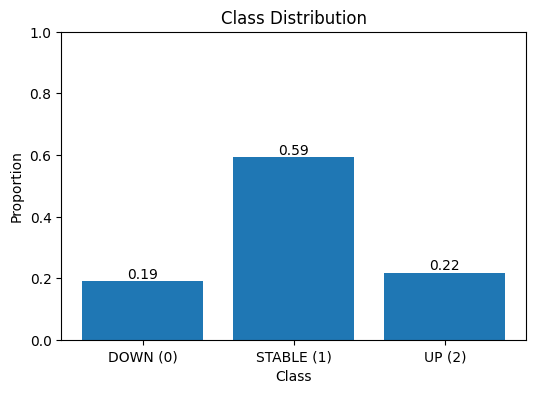

In [20]:
import matplotlib.pyplot as plt

#dodaje se future return
df["future_close_24h"] = df["Close"].shift(-24)# uzimamo cenu 24h u budućnosti
df["future_return_24h"] = (df["future_close_24h"] - df["Close"]) / df["Close"]# Model ne predviđa cenu nego promenu, to je bolje za ML

def classify_direction(x):
    if x > 0.02:
        return 2      # UP
    elif x < -0.02:
        return 0     # DOWN
    else:
        return 1      # STABLE

#izbacuje NaN
df["direction_24h"] = df["future_return_24h"].apply(classify_direction)

df = df.dropna() #posto je ispod 70% stable, (iako bi mozda trebalo class weights da koristim) za sad cu da ostavim ovako
df["direction_24h"].value_counts(normalize=True)

#plot
class_dist = df["direction_24h"].value_counts(normalize=True).sort_index()

labels = ["DOWN (0)", "STABLE (1)", "UP (2)"]

plt.figure(figsize=(6,4))
plt.bar(labels, class_dist.values)

plt.title("Class Distribution")
plt.ylabel("Proportion")
plt.xlabel("Class")

# da se vide brojevi iznad stubova
for i, v in enumerate(class_dist.values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.ylim(0, 1)
plt.show()

<h3>Balansiranje klasa</h3>

<p>
Distribucija klasa pokazuje da je STABLE klasa dominantna. Zbog toga, model može da postigne relativno visoku tačnost čak i bez stvarnog učenja, jednostavno tako što najčešće predviđa većinsku klasu. Model koji bi uvek predviđao klasu STABLE mogao bi da postigne tačnost od 71%, što ne predstavlja stvarno dobar model, već posledicu neuravnoteženosti podataka.
</p>
<p>
Zbog izražene neuravnoteženosti klasa, izračunate su težine koje povećavaju značaj ređih klasa tokom treniranja modela. Ove težine su dobijene korišćenjem funkcije <i>compute_class_weight</i> iz biblioteke scikit-learn.
</p>

<p>
Težine su izračunate na osnovu celokupnog skupa podataka kao aproksimacija distribucije klasa. Iako bi metodološki preciznije bilo računati ih samo na trening skupu, ovaj pristup daje dovoljno dobru procenu odnosa između klasa.
</p>

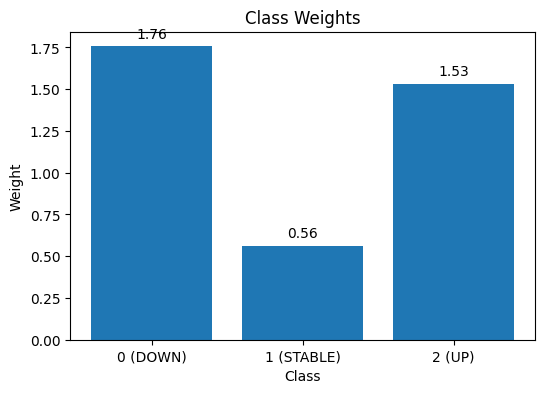

In [21]:
!pip install -q scikit-learn

# kad ima mnogo STABLE dana model voli da vara
# Ovo daje veću kaznu za retke klase.

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=df["direction_24h"]
)

class_weights = dict(zip(classes, weights))

# sortiraj po klasi (0,1,2) da redosled bude lep
sorted_items = sorted(class_weights.items())

labels = [f"{k} ({'DOWN' if k==0 else 'STABLE' if k==1 else 'UP'})" for k, _ in sorted_items]
values = [v for _, v in sorted_items]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Class Weights")
plt.xlabel("Class")
plt.ylabel("Weight")

# vrednosti iznad stubova
for i, v in enumerate(values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center')

plt.show()

<h2><b>1) TEMPORAL SPLIT</b></h2>

Podaci su podeljeni na trening, validacioni i test skup tako da se zadrži vremenski redosled. Nije korišćen random split, jer bi to dovelo do mešanja prošlih i budućih vrednosti, što nije ispravno za vremenske serije.

Korišćen je odnos 60% za trening, 20% za validaciju i 20% za test. Najstariji podaci su korišćeni za treniranje, dok su noviji podaci ostavljeni za validaciju i testiranje, kako bi se bolje simulirala realna situacija predikcije.

In [22]:
# -----------------------------
# 1) TEMPORAL SPLIT
# -----------------------------


# izdvajamo target
target_col = "direction_24h"

features = ["Close", "Volume", "High", "Low"]


# indeks za split (60/20/20)
n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

#najstariji podaci idu za train, onda za vel i na kraju test
train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

<h2>Vizuelizacija distribucije podataka</h2>

Distribucija klasa kroz trening, validacioni i test skup ostaje relativno stabilna, što ukazuje na konzistentnost podataka kroz vreme i omogućava pouzdanu evaluaciju modela. Može se primetiti da distribucija klasa nije potpuno ista između trening i validacionog skupa. Konkretno, STABLE klasa je značajno zastupljenija u validacionom skupu. Ovo ukazuje na promene u tržišnom ponašanju kroz vreme, što je karakteristično za finansijske vremenske serije.

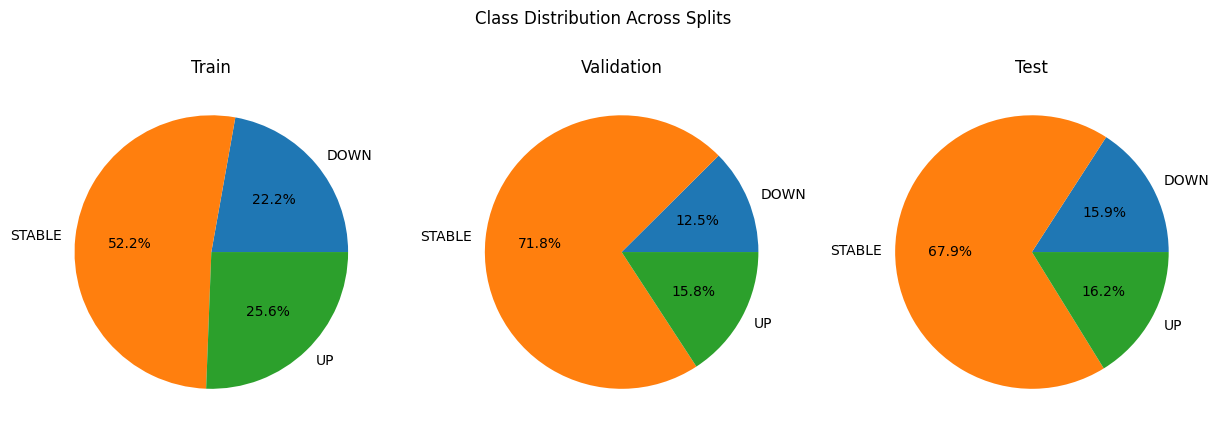

In [23]:
# funkcija za distribuciju
def get_dist(data):
    return data["direction_24h"].value_counts(normalize=True).sort_index()

train_dist = get_dist(train_df)
val_dist   = get_dist(val_df)
test_dist  = get_dist(test_df)

labels = ["DOWN", "STABLE", "UP"]

fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].pie(train_dist.values, labels=labels, autopct='%1.1f%%')
axes[0].set_title("Train")

axes[1].pie(val_dist.values, labels=labels, autopct='%1.1f%%')
axes[1].set_title("Validation")

axes[2].pie(test_dist.values, labels=labels, autopct='%1.1f%%')
axes[2].set_title("Test")

plt.suptitle("Class Distribution Across Splits")
plt.show()

<h2>2) SCALING</h2>

Pre treniranja modela urađena je normalizacija podataka pomoću StandardScaler metode. Ova transformacija skaluje podatke tako da imaju srednju vrednost 0 i standardnu devijaciju 1, što pomaže modelu da lakše uči.

Scaler je fitovan samo na trening podacima, dok su validacioni i test skup samo transformisani. Ovo je važno kako bi se izbeglo korišćenje informacija iz budućnosti prilikom treniranja modela.

In [24]:
# -----------------------------
# 2) SCALING
# -----------------------------

!pip install -q scikit-learn
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# FIT samo na train
train_df.loc[:, features] = scaler.fit_transform(train_df[features])#train_df[features] = scaler.fit_transform(train_df[features])

# TRANSFORM na val i test
val_df[features] = scaler.transform(val_df[features])
test_df[features] = scaler.transform(test_df[features])

<h2>3) Kreiranje sekvenci</h2>

Pošto LSTM model ne radi sa pojedinačnim vrednostima već sa nizovima, podaci su pretvoreni u sekvence pomoću sliding window pristupa. To znači da model kao ulaz dobija poslednjih 24 vrednosti, a zatim pokušava da predvidi klasu kretanja cene u narednom periodu.

Na ovaj način model ne gleda samo trenutnu cenu, već i kontekst iz prethodnog perioda, što je važno kod vremenskih serija. Sekvence su napravljene posebno za trening, validaciju i test skup.

<h3>Dimenzije podataka</h3>

Nakon formiranja sekvenci, podaci su dobili trodimenzionalni oblik. Prva dimenzija predstavlja broj uzoraka, druga dužinu sekvence (window size), dok treća predstavlja broj ulaznih karakteristika. Ovakav format je neophodan za rad sa LSTM modelima koji očekuju sekvencijalne ulaze.

In [25]:
# -----------------------------
# 3) SEQUENCE CREATION
# -----------------------------

import numpy as np

def create_sequences(data, target, window=168):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(target[i+window])# vec je pomereno
    return np.array(X), np.array(y)

window_size = 168

X_train, y_train = create_sequences(
    train_df[features].values,
    train_df[target_col].values,
    window_size
)

X_val, y_val = create_sequences(
    val_df[features].values,
    val_df[target_col].values,
    window_size
)

X_test, y_test = create_sequences(
    test_df[features].values,
    test_df[target_col].values,
    window_size
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (44550, 168, 4)
Validation shape: (14738, 168, 4)
Test shape: (14738, 168, 4)


<h2>4) TORCH DATASET</h2>

Podaci su prilagođeni za rad u PyTorch-u tako što je definisana Dataset klasa koja vraća ulazne sekvence i target vrednosti. Sve vrednosti su konvertovane u tensor format.

Zatim su napravljeni DataLoader objekti koji omogućavaju učitavanje podataka u manjim batch-evima tokom treniranja. Shuffle opcija je isključena kako bi se zadržao vremenski redosled podataka.

In [26]:
# -----------------------------
# 4) TORCH DATASET
# -----------------------------
!pip install -q torch torchvision torchaudio

import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset   = TimeSeriesDataset(X_val, y_val)
test_dataset  = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

<h2>5) PRICE LSTM MODEL</h2>

<p>
Za predikciju smera kretanja cene korišćen je LSTM model, koji je pogodan za rad sa vremenskim serijama jer može da uzme u obzir zavisnosti između prethodnih vrednosti. Model kao ulaz prima sekvence podataka, a kao izlaz daje klasu koja označava da li će cena rasti, padati ili ostati stabilna u narednih 24h.
</p>

<p>
U implementaciji se koristi poslednji izlaz iz sekvence, koji predstavlja informaciju o celokupnom prethodnom kretanju, i prosleđuje se kroz linearni sloj kako bi se dobile logit vrednosti za svaku klasu.
</p>

<h3>Izmena arhitekture modela</h3>

<p>
U početnoj verziji model je imao više LSTM slojeva i veći broj ulaznih karakteristika. Međutim, tokom testiranja primećeno je da složeniji model daje lošije rezultate i veću grešku na validacionom skupu.
</p>

<p>
Zbog toga je model pojednostavljen na jedan LSTM sloj sa manjim brojem neurona i manjim brojem ulaznih karakteristika. Ova verzija se pokazala stabilnijom tokom treniranja i dala je bolje rezultate u odnosu na kompleksniju arhitekturu.
</p>

In [27]:
# -----------------------------
# 5) PRICE LSTM MODEL
# -----------------------------

import torch.nn as nn

class PriceBranch(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.lstm = nn.LSTM(input_size, 168, batch_first=True)
        self.dropout = nn.Dropout(0.2)

        self.fc = nn.Linear(168, 3)  # 3 klase (UP, DOWN, STABLE)

    def forward(self, x):

        out, _ = self.lstm(x)
        out = self.dropout(out)

        out = out[:, -1, :]# Uzima se samo poslednji izlaz iz sekvence
        out = self.fc(out)# Klasifikacija u 3 klase

        return out

<h3>Balansiranje klasa</h3>

<p>
Tokom treniranja modela primećeno je da zbog neuravnoteženosti klasa model ima tendenciju da favorizuje dominantnu klasu (STABLE). U tom slučaju model postiže visoku tačnost (71%), ali zapravo ne uči korisne obrasce, već samo predviđa najčešću klasu.
</p>

<p>
Kako bi se ovaj problem ublažio, uvedene su težine klasa (class weights) u funkciju gubitka. Ideja je da se greške nad ređim klasama (UP i DOWN) više penalizuju u odnosu na dominantnu klasu.
</p>

<p>
U početnoj fazi težine su podešavane ručno, kako bi se eksperimentalno videlo kako utiču na ponašanje modela. Međutim, ovakav pristup nije bio optimalan jer zahteva ručno podešavanje i može dovesti do nestabilnih rezultata.
</p>

<p>
Zbog toga je korišćen algoritam za automatsko računanje težina klasa (compute_class_weight), koji određuje težine na osnovu raspodele podataka. Na ovaj način model dobija uravnotežen signal tokom treniranja i bolje uči da prepoznaje sve klase.
</p>

In [28]:



# prilagodi class weights za 0,1,2
#weights_tensor = torch.tensor(
#    [class_weights[-1], class_weights[0], class_weights[1]],
#    dtype=torch.float32
#).to(device)

#criterion = nn.CrossEntropyLoss(weight=weights_tensor)# classification loss# presao san na rucno unosenje





#optimizer = torch.optim.Adam(model.parameters(), lr=0.001)# ne moze da bira


<h2>6) TRAINING LOOP</h2>

<p>
Model je treniran korišćenjem standardnog procesa treniranja neuronskih mreža. U svakoj epohi model prolazi kroz ceo trening skup podataka, pri čemu se za svaki batch računaju predikcije, funkcija gubitka i ažuriraju težine modela pomoću izabranog optimizatora.
</p>

<p>
Za optimizaciju su testirani različiti optimizatori (Adam, SGD i RMSprop), kako bi se ispitao njihov uticaj na performanse modela. Kao funkcija gubitka korišćen je CrossEntropyLoss sa dodatim težinama klasa, čime se penalizuju greške nad ređim klasama (UP i DOWN).
</p>

<h3>Validacija i evaluacija modela</h3>

<p>
Nakon svake epohe model se evaluira na validacionom skupu. Tokom evaluacije računaju se metrike kao što su tačnost (accuracy), F1 skor i directional accuracy. Pored toga, prikazuje se i konfuziona matrica koja omogućava detaljniju analizu performansi modela po klasama.
</p>

<p>
Zbog neuravnoteženosti klasa, posebna pažnja posvećuje se F1 skoru i raspodeli predikcija, jer tačnost sama po sebi može dati varljiv utisak o kvalitetu modela.
</p>

<h3>Stabilizacija treniranja</h3>

<p>
Kako bi se poboljšala stabilnost treniranja, primenjen je gradient clipping, koji ograničava vrednosti gradijenata i sprečava nestabilnosti tokom učenja.
</p>

<p>
Takođe, korišćen je learning rate scheduler koji automatski smanjuje brzinu učenja ukoliko se validaciona funkcija gubitka ne poboljšava, što omogućava preciznije podešavanje modela u kasnijim fazama treniranja.
</p>

<h3>Early stopping</h3>

<p>
Uveden je i mehanizam za rano zaustavljanje treniranja (early stopping). Ukoliko se validaciona funkcija gubitka ne poboljšava tokom određenog broja epoha, treniranje se prekida kako bi se izbegao overfitting i sačuvale najbolje performanse modela.
</p>

In [33]:
# -----------------------------
# 6) TRAINING LOOP
# -----------------------------
!pip install -q seaborn

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#optimizer = get_optimizer(optimizer_type='adam', lr=0.001)# da moze da bira

def training_loop(optimizer_type='adam', lr=0.001, epochs=20):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = PriceBranch(input_size=len(features)).to(device)

    if optimizer_type == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_type == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unsupported optimizer type: {optimizer_type}")

    weights_tensor = torch.tensor(
        [class_weights[0], class_weights[1], class_weights[2]],
        dtype=torch.float32
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
##############################################
    # Ručno dodeljene težine za klase
    # Povećaj težinu za manje zastupljene klase (UP i DOWN), smanji za STABLE
    #class_weights = torch.tensor([12, 4.5, 17], dtype=torch.float32).to(device)#prvo je ovo [18, 6, 29.5] onda je [18, 6, 20] bilo bolje

    # Kreiraj funkciju gubitka sa težinama
    #criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
###############################################
    # learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    # -----------------------------
    # |||| Early stopping setup ||||
    # -----------------------------
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0

    #epochs = 20

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)  # Model predviđa
            loss = criterion(outputs, y_batch)  # Koliko je model pogrešio
            loss.backward()  # Računanje gradijenata
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.8)  # Stabilizacija treninga (gradient clipping)
            optimizer.step()  # Model uči

            train_loss += loss.item()

        train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_preds = []
        val_true = []
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1).cpu().numpy()# predviđanje klasa za klasifikaciju
                val_preds.extend(preds)
                val_true.extend(y_batch.cpu().numpy())
        val_loss = val_loss / len(val_loader)

        # score evaluacija
        acc = accuracy_score(val_true, val_preds)
        directional_accuracy = np.mean(np.array(val_preds) == np.array(val_true))
        f1 = f1_score(val_true, val_preds, average='weighted')  
        conf_matrix = confusion_matrix(val_true, val_preds)
        print(f"Epoch {epoch+1} | Optimizer : {optimizer_type} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Validation[ Acc: {acc:.4f} | "
            f"Directional Accuracy: {directional_accuracy:.4f} | "
            f"F1: {f1:.4f} ]")
        print(f"\nConfusion Matrix: \n{conf_matrix}\n")
        print("Pred class distribution:", np.bincount(val_preds, minlength=3))
        print("True class distribution:", np.bincount(val_true, minlength=3))

        # Check for early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print("Early stopping...")
            break
        
        # Scheduler za smanjenje learning rate-a
        scheduler.step(val_loss)#scheduler.step(train_loss)

    #confusion matrix plot
    cm = confusion_matrix(val_true, val_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["DOWN", "STABLE", "UP"],
                yticklabels=["DOWN", "STABLE", "UP"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    #distribucija predikcije i stvarne vrednosti

    plt.show()

    labels = ["DOWN", "STABLE", "UP"]

    true_counts = np.bincount(val_true, minlength=3)
    pred_counts = np.bincount(val_preds, minlength=3)

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(6,4))
    plt.bar(x - width/2, true_counts, width, label="True")
    plt.bar(x + width/2, pred_counts, width, label="Predicted")

    plt.xticks(x, labels)
    plt.ylabel("Count")
    plt.title("True vs Predicted Class Distribution")
    plt.legend()

    plt.show()
        

Epoch 1 | Optimizer : adam | Train Loss: 1.0858 | Val Loss: 1.0829 | Validation[ Acc: 0.4534 | Directional Accuracy: 0.4534 | F1: 0.5027 ]

Confusion Matrix: 
[[ 935  634  257]
 [3929 5312 1317]
 [1183  736  435]]

Pred class distribution: [6047 6682 2009]
True class distribution: [ 1826 10558  2354]
Epoch 2 | Optimizer : adam | Train Loss: 1.0908 | Val Loss: 1.0834 | Validation[ Acc: 0.4275 | Directional Accuracy: 0.4275 | F1: 0.4817 ]

Confusion Matrix: 
[[ 890  563  373]
 [3915 4862 1781]
 [1152  654  548]]

Pred class distribution: [5957 6079 2702]
True class distribution: [ 1826 10558  2354]
Epoch 3 | Optimizer : adam | Train Loss: 1.0935 | Val Loss: 1.0850 | Validation[ Acc: 0.4078 | Directional Accuracy: 0.4078 | F1: 0.4640 ]

Confusion Matrix: 
[[ 898  524  404]
 [4047 4531 1980]
 [1203  570  581]]

Pred class distribution: [6148 5625 2965]
True class distribution: [ 1826 10558  2354]
Epoch 4 | Optimizer : adam | Train Loss: 1.0940 | Val Loss: 1.0859 | Validation[ Acc: 0.4003 |

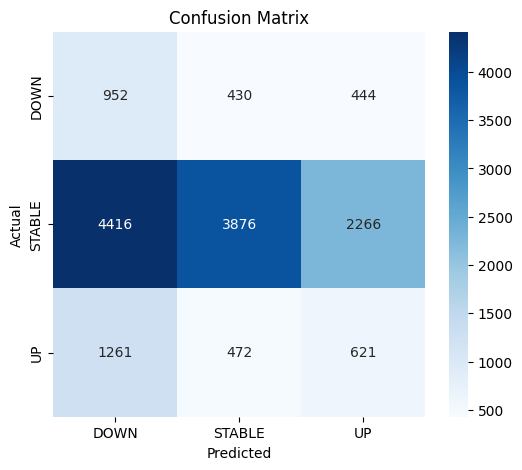

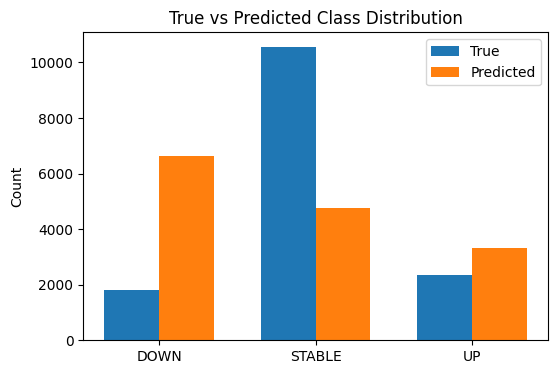

In [36]:
training_loop(optimizer_type='adam', lr=0.0001, epochs=5)

<h2>Opis grafika</h2>
<p>
Distribucija predikcija pokazuje da model češće predviđa STABLE klasu u odnosu na stvarnu raspodelu, što potvrđuje uticaj neuravnoteženosti podataka.
</p>

Epoch 1 | Optimizer : sgd | Train Loss: 1.0994 | Val Loss: 1.0982 | Validation[ Acc: 0.2907 | Directional Accuracy: 0.2907 | F1: 0.2828 ]

Confusion Matrix: 
[[   0  198 1628]
 [   0 2170 8388]
 [   0  239 2115]]

Pred class distribution: [    0  2607 12131]
True class distribution: [ 1826 10558  2354]
Epoch 2 | Optimizer : sgd | Train Loss: 1.0956 | Val Loss: 1.0889 | Validation[ Acc: 0.4893 | Directional Accuracy: 0.4893 | F1: 0.5146 ]

Confusion Matrix: 
[[  60  705 1061]
 [ 376 5737 4445]
 [  49  890 1415]]

Pred class distribution: [ 485 7332 6921]
True class distribution: [ 1826 10558  2354]
Epoch 3 | Optimizer : sgd | Train Loss: 1.0937 | Val Loss: 1.0847 | Validation[ Acc: 0.5267 | Directional Accuracy: 0.5267 | F1: 0.5596 ]

Confusion Matrix: 
[[ 511  821  494]
 [1867 6583 2108]
 [ 609 1077  668]]

Pred class distribution: [2987 8481 3270]
True class distribution: [ 1826 10558  2354]
Epoch 4 | Optimizer : sgd | Train Loss: 1.0926 | Val Loss: 1.0834 | Validation[ Acc: 0.5307 | 

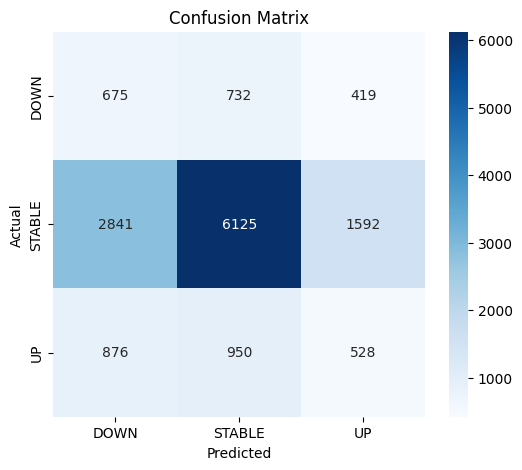

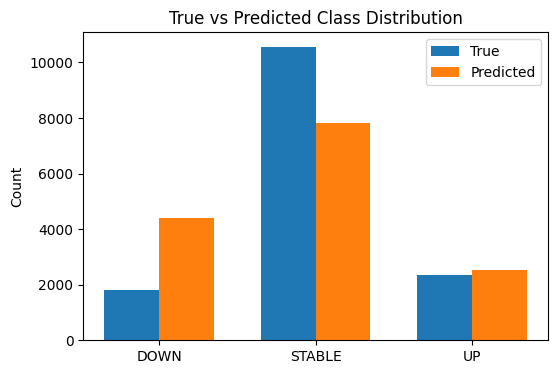

In [35]:
training_loop(optimizer_type='sgd', lr=0.0001, epochs=5)# manji learn rate za sgd

Epoch 1 | Optimizer : rmsprop | Train Loss: 1.0766 | Val Loss: 1.0875 | Validation[ Acc: 0.4271 | Directional Accuracy: 0.4271 | F1: 0.4727 ]

Confusion Matrix: 
[[1150  574  102]
 [4818 4937  803]
 [1493  654  207]]

Pred class distribution: [7461 6165 1112]
True class distribution: [ 1826 10558  2354]
Epoch 2 | Optimizer : rmsprop | Train Loss: 1.0739 | Val Loss: 1.0885 | Validation[ Acc: 0.4104 | Directional Accuracy: 0.4104 | F1: 0.4643 ]

Confusion Matrix: 
[[ 985  516  325]
 [4195 4543 1820]
 [1241  592  521]]

Pred class distribution: [6421 5651 2666]
True class distribution: [ 1826 10558  2354]
Epoch 3 | Optimizer : rmsprop | Train Loss: 1.0718 | Val Loss: 1.0880 | Validation[ Acc: 0.4064 | Directional Accuracy: 0.4064 | F1: 0.4615 ]

Confusion Matrix: 
[[ 963  504  359]
 [4234 4488 1836]
 [1244  572  538]]

Pred class distribution: [6441 5564 2733]
True class distribution: [ 1826 10558  2354]
Epoch 4 | Optimizer : rmsprop | Train Loss: 1.0719 | Val Loss: 1.0877 | Validation[ A

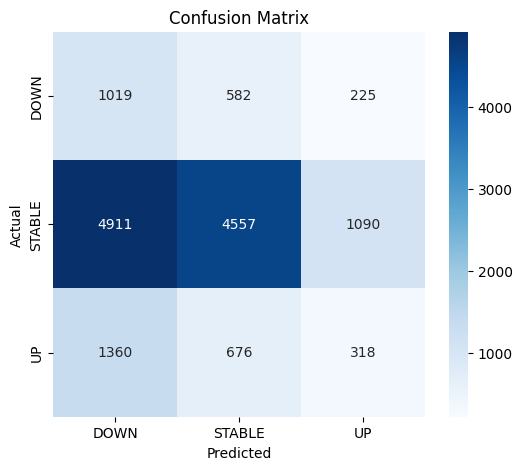

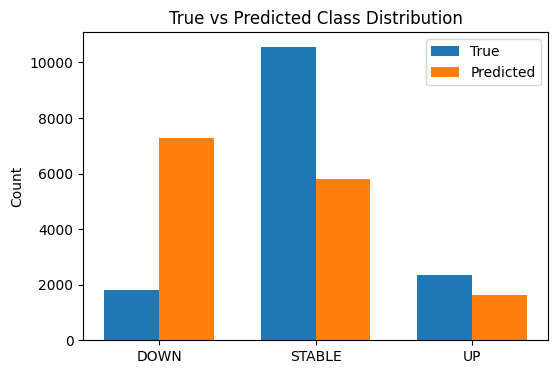

In [34]:
training_loop(optimizer_type='rmsprop', lr=0.0001, epochs=5)

<h3>Uticaj optimizatora i analiza performansi</h3>

<p>
Rezultati klasifikacionog modela pokazuju da model postiže tačnost od oko 60%, što na prvi pogled može delovati zadovoljavajuće. Međutim, detaljnija analiza distribucije klasa i konfuzione matrice otkriva značajna ograničenja modela.
</p>

<p>
Dataset je neuravnotežen, sa dominantnom klasom STABLE koja čini većinu uzoraka. Kao posledica toga, model pokazuje tendenciju da favorizuje ovu klasu, što se ogleda u velikom broju predikcija koje pripadaju upravo STABLE kategoriji.
</p>

<p>
Konfuziona matrica pokazuje da model često pogrešno klasifikuje UP i DOWN primere kao STABLE, što ukazuje na ograničenu sposobnost modela da prepozna značajnije promene u kretanju cene.
</p>

<p>
Ovakvo ponašanje dovodi do toga da ukupna tačnost ostaje relativno visoka, iako model ne uspeva da precizno detektuje ključne promene koje su najvažnije za praktičnu primenu.
</p>

<p>
Ovaj problem je karakterističan za neuravnotežene klasifikacione zadatke, gde model optimizuje ukupnu tačnost nauštrb performansi na manjinskim klasama. Uvođenje težina klasa u funkciju gubitka donekle ublažava ovaj problem, ali rezultati i dalje pokazuju da je zadatak predikcije smera kretanja cene znatno složeniji od same regresije vrednosti.
</p>